In [ ]:
import csv
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.interpolate import interp1d, splrep, splev
from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler
from statsmodels.nonparametric.smoothers_lowess import lowess

def lowess_smooth (data):
    x = np.linspace(0, 1, len(data))
    y = data

    frac = 0.05
    lowess_result = lowess(y, x, frac=frac)

    return lowess_result[:,1]

def normalize_data(list):
    list_max = max(list)
    normalized_data_1d = [ (data / list_max)for data in list]
    return normalized_data_1d


def moving_average(x, window=7):
    x = np.asarray(x, dtype=float)
    pad = window // 2
    x_pad = np.pad(x, pad, mode='edge')
    kernel = np.ones(window) / window
    return np.convolve(x_pad, kernel, mode='valid')

def find_edges_monotonic(trace, smooth_window=7):
    trace = np.asarray(trace, dtype=float)
    smoothed = moving_average(trace, window=smooth_window)
    n = len(smoothed)

    # ---------- left ----------
    left_edge = 0
    for i in range(1, n):
        if smoothed[i] < smoothed[i - 1]:
            left_edge = i - 1
            break

    # ---------- right ----------
    right_edge = n - 1
    for i in range(n - 2, -1, -1):
        if smoothed[i] < smoothed[i + 1]:
            right_edge = i + 1
            break

    return left_edge, right_edge, smoothed

def interpolate_data(values, num=1000):
    values = np.asarray(values, dtype=float)
    x = np.linspace(0, 1000, len(values))
    spl = splrep(x, values)
    new_x = np.linspace(0, 1000, num)
    new_values = splev(new_x, spl)
    return new_x, new_values

def normalize_by_max(values):
    values = np.asarray(values, dtype=float)
    vmax = values.max()
    
    if vmax == 0:
        return values
    
    return values / vmax

def find_optimal_split_point(trace, start=300, end=700, interp_num=1000):
    trace = np.asarray(trace, dtype=float)

    best_split = None
    best_corr = -np.inf

    for i in range(start, end + 1):
        left_arm = trace[:i]
        right_arm = trace[i:]

        _, interpolate_left = interpolate_data(left_arm, num=interp_num)
        _, interpolate_right = interpolate_data(right_arm, num=interp_num)

        corr, _ = pearsonr(interpolate_left[::-1], interpolate_right)

        if corr > best_corr:
            best_corr = corr
            best_split = i

    return best_split, best_corr



def enlongate_based_on_optimal_split_point(trace, best_split):
    left_arm = trace[:best_split]
    right_arm = trace[best_split:]
    _, interpolate_left = interpolate_data(left_arm, num=1000)
    _, interpolate_right = interpolate_data(right_arm, num=1000)
    whole_list = interpolate_left.tolist() + interpolate_right.tolist()
    data = whole_list[::2]
    return data


def optimal_split_point_packaged(red_values, green_values):
    # _, red_values = interpolate_data(red_value, num=1000)
    best_split, _ = find_optimal_split_point(red_values, start=300, end=700, interp_num=1000)

    red_trace = enlongate_based_on_optimal_split_point(red_values, best_split)

    # _, green_values = interpolate_data(green_value, num=1000)
    green_trace = enlongate_based_on_optimal_split_point(green_values, best_split)

    return red_trace, green_trace

def interpolate_data_b(x, y, num):
    spl = splrep(x, y)  
    new_x = np.linspace(min(x), max(x), num)  
    new_value = splev(new_x, spl)
    return new_value

def half_data (list, num):
    num_r = math.ceil(num/2)
    front_half = list[:num_r]
    back_half = list[num_r:]
    front_half_reversed = front_half[::-1]
    
    return front_half_reversed,back_half

def fraction (list):
    total_sum = sum(list)
    cumulative_sum = []
    current_sum = 0
    for value in list:
        current_sum += value
        cumulative_sum.append(current_sum)
    cumulative_weights = [(cs / total_sum)for cs in cumulative_sum]
    return cumulative_weights


def figure_3_create(new_red,new_green):
    # Green
    front_green,back_green = half_data (new_green, len(new_green))
    x_front = fraction (front_green)
    x_back = fraction (back_green)

    # Red
    front_red,back_red = half_data (new_red, len(new_red))

    #Integrate
    intensity_front = interpolate_data_b (x_front, front_red, 1000)
    intensity_front = normalize_data(intensity_front)

    intensity_back = interpolate_data_b (x_back, back_red, 1000)
    intensity_back = normalize_data(intensity_back)

    return intensity_front, intensity_back

def ave_center_data(data):
    n = len(data)

    start = int(n * 0.495)
    end = int(n * 0.595)
    middle_1_percent = data[start:end]

    baseline = sum(middle_1_percent) / len(middle_1_percent) 
    
    return baseline


def fig_4_create (new_red,new_green):
    
    # Green
    front_green,back_green = half_data (new_green, len(new_green))

    x_front = fraction (front_green)

    x_back = fraction (back_green)

    # Red

    baseline = ave_center_data (new_red)
    front_red,back_red = half_data (new_red, len(new_red))

    front_red_b = [(x/baseline) - 1 for x in front_red]
    back_red_b = [(x/baseline) - 1 for x in back_red]

    intensity_front = interpolate_data_b(x_front, front_red_b, 1000)
    intensity_back = interpolate_data_b(x_back, back_red_b, 1000)

    return intensity_front, intensity_back



def allinfunction_optimal_point(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

    red_values_list = []
    green_values_list = []
    fig_3_intensities = []
    fig_4_intensities = []

    for file in csv_files: # range(0,len(df['Red_intensity']))
        try:
            df = pd.read_csv(os.path.join(folder_path, file))
            red_cell = df.iloc[:, 2].tolist() 
            green_cell = df.iloc[:, 1].tolist() 
            new_green, new_red = adjust_the_line_new (green_cell, red_cell)
            red_cell, green_cell = optimal_split_point_packaged(new_red, new_green)
            red_cell = lowess_smooth(red_cell)
            green_cell = lowess_smooth(green_cell)

            # This is figure 1 & 2 parts
            normalized_red_value = normalize_data(red_cell)
            normalized_green_value = normalize_data(green_cell)
            red_values_list.append(normalized_red_value)
            green_values_list.append(normalized_green_value)

            # This is figure 3 part
            intensity_front_3, intensity_back_3 = figure_3_create(red_cell,green_cell)
            fig_3_intensities.append(intensity_front_3)
            fig_3_intensities.append(intensity_back_3)

            # This is figure 4 part
            intensity_front_4, intensity_back_4 = fig_4_create (red_cell,green_cell)
            signal = [(a + b)/2 for a, b in zip(intensity_front_4, intensity_back_4)]
            fig_4_intensities.append(signal)


        except Exception as e:
            print('error in {}'.format(file))

    return red_values_list, green_values_list, fig_3_intensities, fig_4_intensities

def adjust_the_line_new (green_cell, red_cell):
    _, green_cell = interpolate_data(green_cell, num=1000)
    _, red_cell = interpolate_data(red_cell, num=1000)
    left_edge, right_edge, _= find_edges_monotonic(green_cell, smooth_window=7)
    _, green_cell_cell = interpolate_data(green_cell[left_edge-5:right_edge+5], num=1000)
    _, red_cell_cell = interpolate_data(red_cell[left_edge-5:right_edge+5], num=1000)

    return green_cell_cell, red_cell_cell
    
def calculate_plot_parameter(intensities):
    average = np.mean(intensities, axis=0)
    stderr = np.std(intensities, axis=0) / np.sqrt(len(intensities))
    stderr = lowess_smooth(stderr)

    std = np.std(intensities, axis=0)
    std = lowess_smooth(std)

    return average, stderr, std



# Figure 2D

In [2]:

def plot_4 (intensities, average, stderr, std):  
    for data in intensities:
        plt.plot(data, color='#b6b4b4', alpha=0.65,linewidth=0.5)

    plt.plot(average, color='#E87373', linewidth=3, label='Average')
    plt.fill_between(range(len(average)), average - stderr, average + stderr, color="#F39B9B", alpha=0.45)
    plt.fill_between(range(len(average)), average - std, average + std, color='#F39B9B', alpha=0.15)

    plt.xticks([0, len(average)//2, len(average)-1], [0, 0.5, 1])
    plt.yticks([-1, 0])
    plt.xlim(0, len(average)-1)
    plt.ylim(-1, 0.8)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Fraction of green intensity line integral from center")
    plt.ylabel("Red intensity change from baseline")


    plt.show()

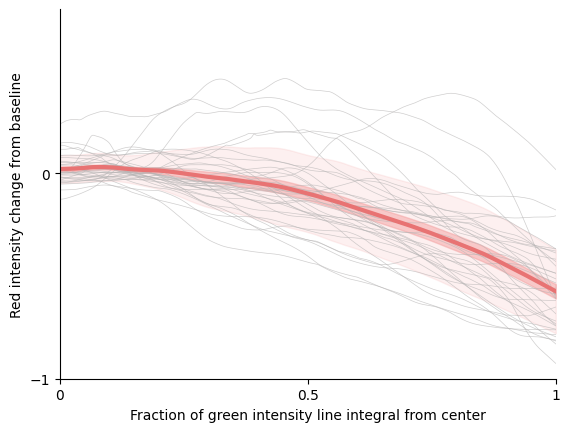

In [ ]:
file_path = r"neuron SMASh 72h data all"

red_values_list, green_values_list, fig_3_intensities, fig_4_intensities = allinfunction_optimal_point(file_path)

average_72, stderr_72, std_72 = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average_72, stderr_72, std_72)

In [5]:
def plot_4 (intensities, average, stderr, std):  
    for data in intensities:
        plt.plot(data, color='#b6b4b4', alpha=0.65,linewidth=0.5)

    plt.plot(average, color='#313131', linewidth=3, label='Average')
    plt.fill_between(range(len(average)), average - stderr, average + stderr, color='gray', alpha=0.45)
    plt.fill_between(range(len(average)), average - std, average + std, color='gray', alpha=0.15)

    plt.xticks([0, len(average)//2, len(average)-1], [0, 0.5, 1])
    plt.yticks([-1, 0])
    plt.xlim(0, len(average)-1)
    plt.ylim(-1, 0.8)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Fraction of green intensity line integral from center")
    plt.ylabel("Red intensity change from baseline")


    plt.show()


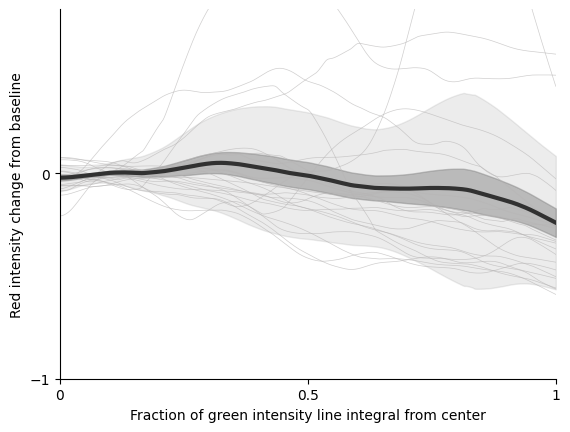

In [ ]:
file_path = r"neuron SMASh control data all"

red_values_list, green_values_list, fig_3_intensities, fig_4_intensities = allinfunction_optimal_point(file_path)

average_control, stderr_control, std_control = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average_control, stderr_control, std_control)

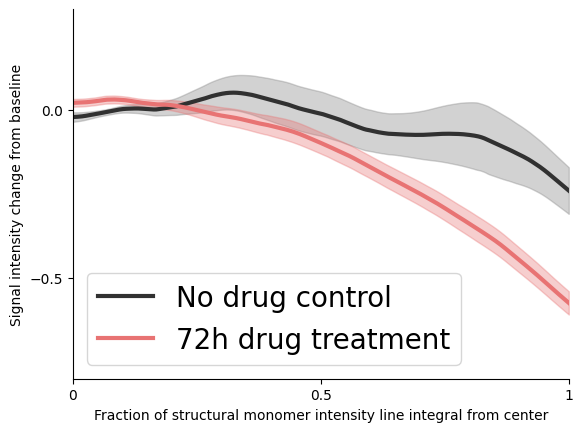

In [7]:
plt.plot(average_control, color="#313131", linewidth=3, label='No drug control')
plt.fill_between(range(len(average_control)), average_control - stderr_control, average_control + stderr_control, color='gray', alpha=0.35)

plt.plot(average_72, color="#E87373", linewidth=3, label='72h drug treatment')
plt.fill_between(range(len(average_72)), average_72 - stderr_72, average_72 + stderr_72, color='#E87373', alpha=0.35)

plt.xticks([0, len(average_control)//2, len(average_control)-1], [0, 0.5, 1])
plt.yticks([-0.5, 0])
plt.xlim(0, len(average_control)-1)
plt.ylim(-0.8, 0.3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xlabel("Fraction of structural monomer intensity line integral from center")
plt.ylabel("Signal intensity change from baseline")

plt.legend(fontsize = 20)
plt.show()

# Figure 2E

In [ ]:
file_path = r"neuron SMASh 72h data all"
red_values_list, green_values_list, fig_3_intensities, fig_4_intensities_72 = allinfunction_optimal_point(file_path)

file_path = r"neuron SMASh control data all"
red_values_list, green_values_list, fig_3_intensities, fig_4_intensities_control = allinfunction_optimal_point(file_path)

In [22]:
begin_avg = [lst[-1] for lst in fig_4_intensities_72]
print(begin_avg)

[-0.38738740199593785, -0.7587152856762546, -0.4860115201607737, -0.6196691750142483, -0.5588676789553205, -0.5135464570257433, 0.018874218488837524, -0.41781185404273913, -0.9254578534868392, -0.7189545321705482, -0.1778266431715249, -0.6833377387654722, -0.42913158894387177, -0.7617951944691277, -0.533306093992932, -0.4863391698155109, -0.378099286882991, -0.6072649689507219, -0.5891579843442045, -0.8159593727482815, -0.8305511825332744, -0.36751892548652626, -0.739366784978199, -0.36693606199560014, -0.7426555926739273, -0.7323573862076856, -0.6508422639235023, -0.5941442974533637, -0.7954843124735036, -0.6094267022797194, -0.81207155930874, -0.7855399854392962, -0.4511175465084417, -0.2062840786643878, -0.5873617481896447]


In [23]:
end_avg = [lst[-1] for lst in fig_4_intensities_control]
print(end_avg)

[-0.43248165549032686, -0.5581584458767918, -0.5629806112038437, -0.5030455517498358, -0.2679520893330707, -0.5111053585150023, -0.251709714197292, -0.589452293599799, 0.5807877504069081, -0.026172966409745146, 0.4782472750281781, -0.33951627870430756, -0.26418156117991565, -0.253111504288407, -0.3676333759932991, -0.324338775929947, -0.2335372679304249, -0.33111659558267653, -0.3945499067215948, 0.4242412886968835, -0.47002105289220797, -0.08250991010118186]


# Figure 2C

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_single_trace_separate(
    green_path,
    red_path,
    figsize=(5, 1.5),
    linewidth=7,
    alpha=0.8,
    pad_ylim=0.1,
    show_axis=False
):
    green_df = pd.read_csv(green_path, skiprows=[1])
    red_df = pd.read_csv(red_path, skiprows=[1])

    green_df = green_df.iloc[:, 1]
    red_df = red_df.iloc[:, 1]

    _, green_trace = interpolate_data(green_df[::-1], num=1000)
    _, red_trace = interpolate_data(red_df[::-1], num=1000)

    green_trace = lowess_smooth(green_trace)
    red_trace = lowess_smooth(red_trace)

    green_norm = normalize_by_max(green_trace)
    red_norm = normalize_by_max(red_trace)

    traces = {
        "all": {
            "data": [green_norm, red_norm],
            "colors": ["#8cc63f", "#f87977"],
        },
        "green": {
            "data": [green_trace],
            "colors": ["#8cc63f"],
        },
        "red": {
            "data": [red_trace],
            "colors": ["#f87977"],
        }
    }

    for name, item in traces.items():
        fig, ax = plt.subplots(figsize=figsize, dpi=300)

        for y, color in zip(item["data"], item["colors"]):
            ax.plot(y, color=color, linewidth=linewidth, alpha=alpha)

        all_y = np.concatenate([np.asarray(y) for y in item["data"]])
        yrange  = np.nanmax(all_y)-np.nanmin(all_y)
        ax.set_ylim(
            np.nanmin(all_y) - 0.1 * yrange,
            np.nanmax(all_y) + 0.1 * yrange
        )

        if not show_axis:
            ax.axis("off")
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.show()

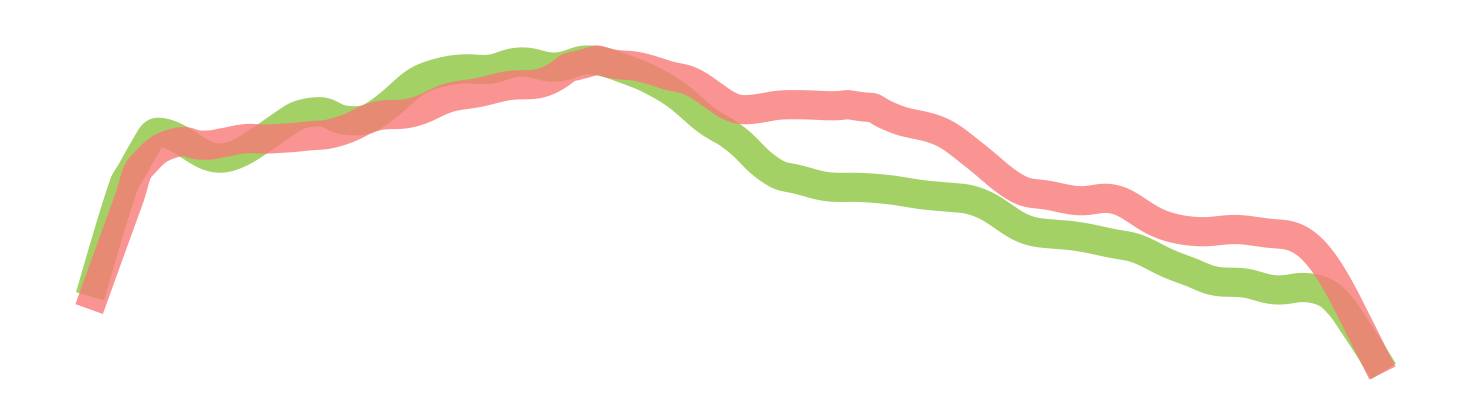

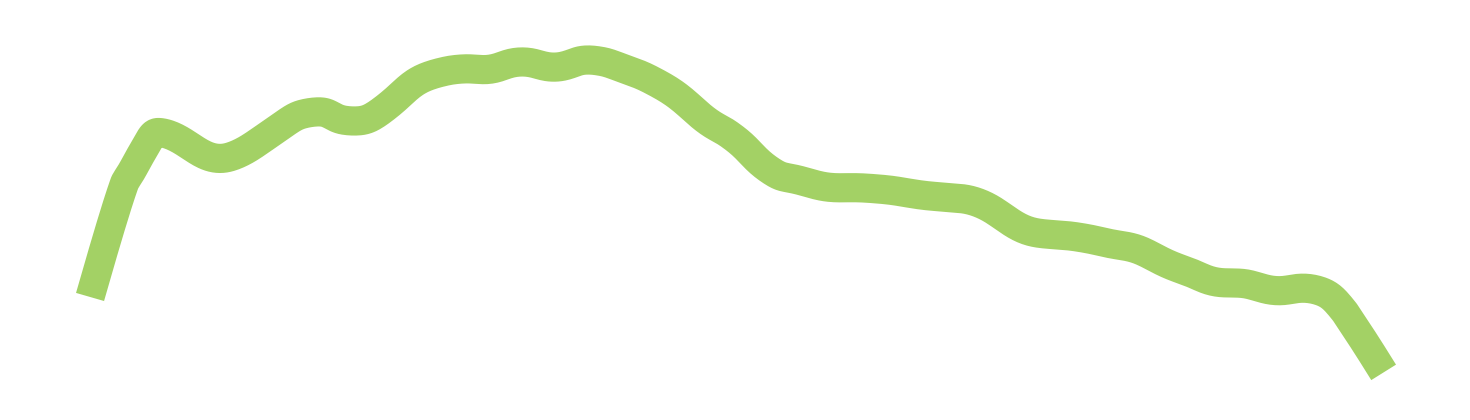

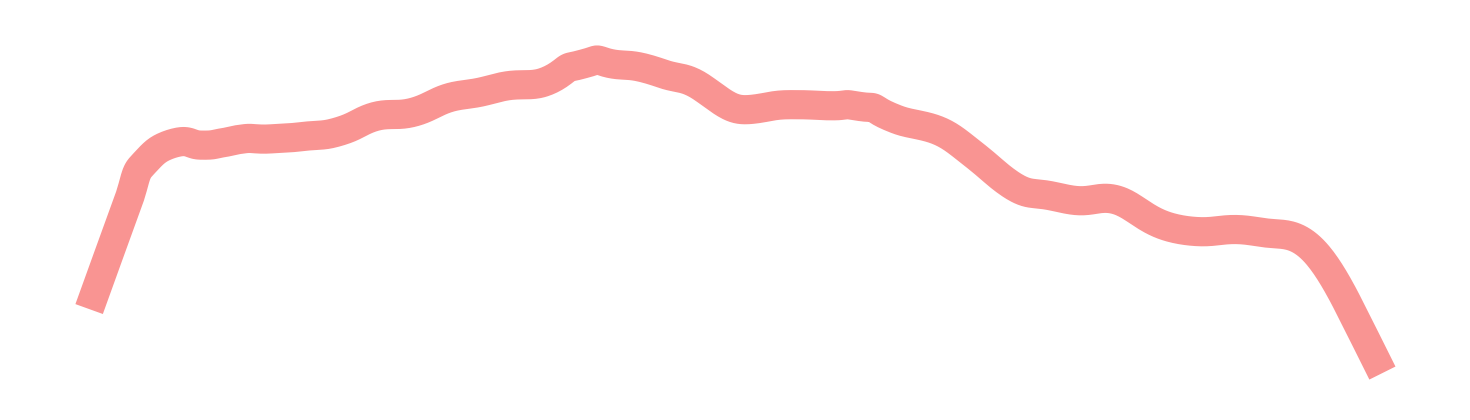

In [ ]:
green_path = r'single trace examples\control green 001.csv'
red_path = r'single trace examples\control red 001.csv'

plot_single_trace_separate(
    green_path,
    red_path,
    figsize=(5, 1.5),
    linewidth=7,
    alpha=0.8,
    pad_ylim=0.2,
    show_axis=False
)

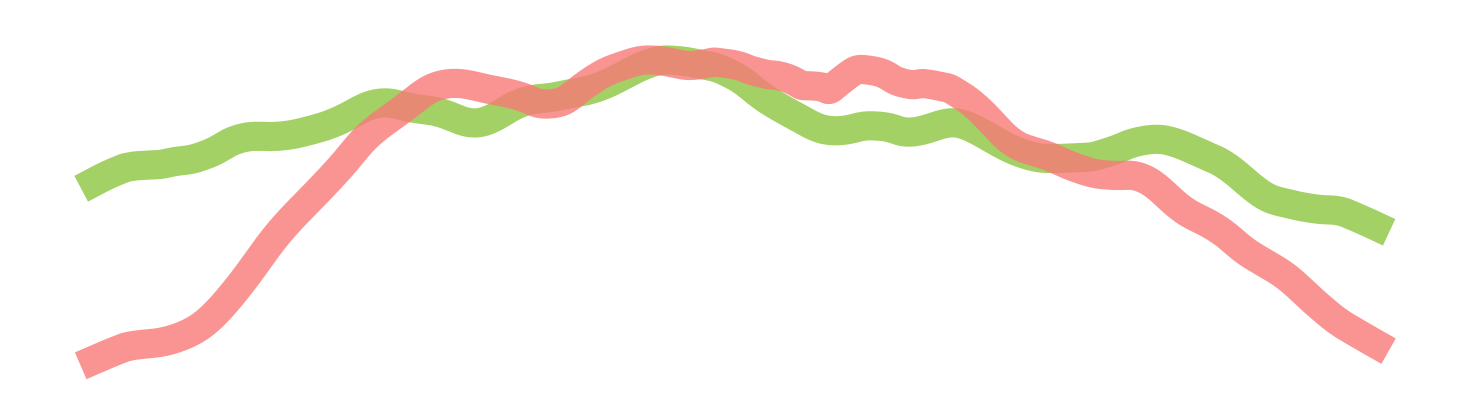

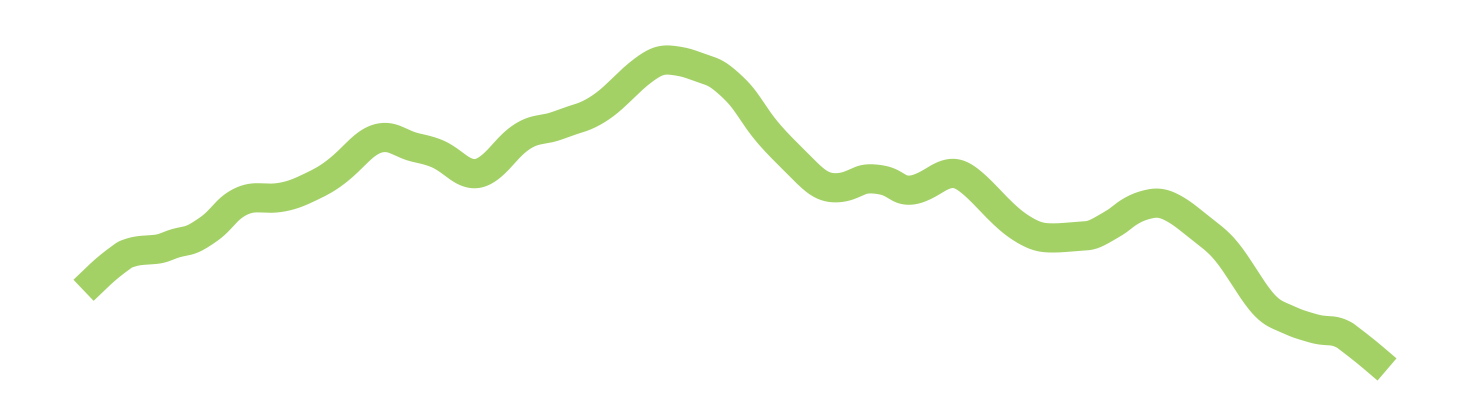

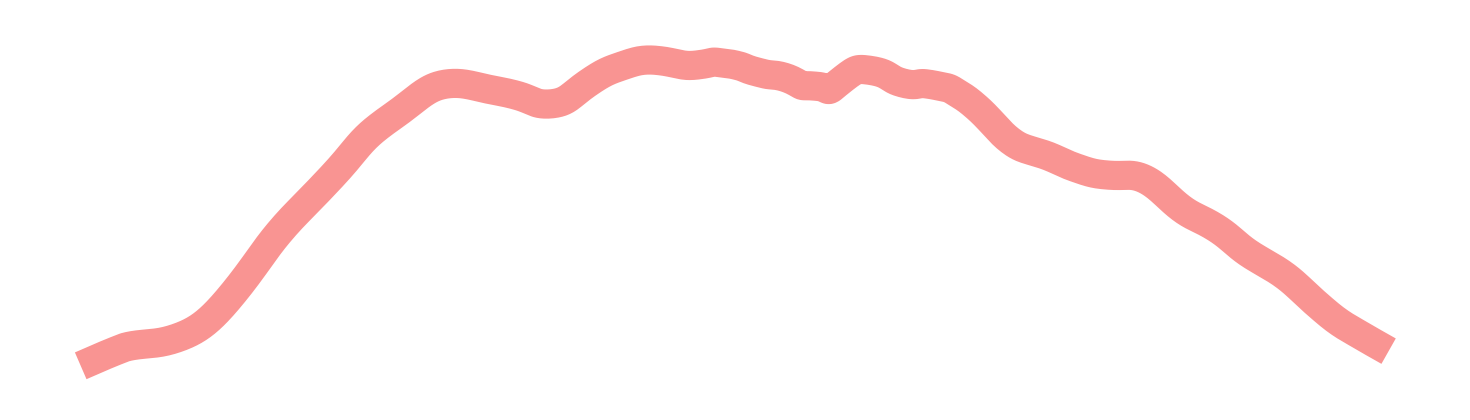

In [ ]:
green_path = r'single trace examples\drug green 001.csv'
red_path = r'single trace examples\drug red 001.csv'

plot_single_trace_separate(
    green_path,
    red_path,
    figsize=(5, 1.5),
    linewidth=7,
    alpha=0.8,
    pad_ylim=0.2,
    show_axis=False
)